In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
import statistics
import random
import math
from scipy import mean

# Import the datasets

In [15]:
#the characteristic mutations list for each subvariants was retrieved from outbreakinfo.org 
omicron = pd.read_excel("omicron_variant_outbreakinfo.xlsx")

In [16]:
#Importing Epitopes
tcell= pd.read_csv("tcell_full_v3_header.csv", sep=",", index_col=0,low_memory=False)
bcell= pd.read_csv("bcell_full_v3_header.csv", sep=",", index_col=0,low_memory=False)

print('The entries of Tcell dataset:', len(tcell))
print('The entries of Bcell dataset:', len(bcell))

C:\Users\Asus\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


The entries of Tcell dataset: 504901
The entries of Bcell dataset: 1387901


In [17]:
#filtering the epitopes datasets
tcell_sars2= tcell[tcell["Epitope_Species"]== "Severe acute respiratory syndrome coronavirus 2"]
tcell_lin = tcell_sars2[tcell_sars2["Epitope_Object Type"]== "Linear peptide"]

tcell_lin= tcell_lin[["Epitope_Molecule Parent", "Epitope_Name", "Epitope_Starting Position", "Epitope_Ending Position"]]
tcell_lin= tcell_lin.drop_duplicates()
tcell_lin.index= range(len(tcell_lin))

bcell_sars2= bcell[bcell["Epitope_Species"]== "Severe acute respiratory syndrome coronavirus 2"]
bcell_lin = bcell_sars2[bcell_sars2["Epitope_Object Type"]== "Linear peptide"]

bcell_lin= bcell_lin[["Epitope_Molecule Parent", "Epitope_Name", "Epitope_Starting Position", "Epitope_Ending Position"]]
bcell_lin= bcell_lin.drop_duplicates()
bcell_lin.index= range(len(bcell_lin))


In [18]:
print('The types of T cell epitopes with their counts:')
tcell_sars2["Epitope_Object Type"].value_counts()

The types of T cell epitopes with their counts:


Linear peptide           22752
Discontinuous peptide       22
Name: Epitope_Object Type, dtype: int64

In [19]:
print('The hosts of T cell epitopes with their counts:')
tcell_sars2["Host_Name"].value_counts()

The hosts of T cell epitopes with their counts:


Homo sapiens (human)               19112
Mus musculus BALB/c                 1502
Mus musculus C57BL/6                1493
Mus musculus HLA-A*02:01 Tg          313
Mus musculus IFNR null               136
Mus musculus HLA-DRB1*04:01 Tg       108
Mus musculus HLA-DRB1*01:01 Tg        85
Macaca mulatta (rhesus macaque)       19
Mus musculus HLA-A*11:01 Tg            5
Mus musculus (mouse)                   1
Name: Host_Name, dtype: int64

In [20]:
print('The source proteins of T cell epitopes with their counts:')
tcell_lin["Epitope_Molecule Parent"].value_counts()

The source proteins of T cell epitopes with their counts:


Spike glycoprotein                 2794
Replicase polyprotein 1ab          1716
Nucleoprotein                       603
Membrane protein                    326
ORF3a protein                       171
Envelope small membrane protein      86
ORF8 protein                         72
ORF7a protein                        69
ORF6 protein                         29
ORF9b protein                        18
ORF10 protein                        14
Putative ORF9c protein               10
ORF7b protein                         9
Replicase polyprotein 1a              8
Name: Epitope_Molecule Parent, dtype: int64

In [21]:
print('The types of B cell epitopes with their counts:')
bcell_sars2["Epitope_Object Type"].value_counts()

The types of B cell epitopes with their counts:


Linear peptide                          79364
Discontinuous peptide                   10679
Discontinuous peptide on multi chain      301
Name: Epitope_Object Type, dtype: int64

In [22]:
print('The types of B cell epitopes with their counts:')
bcell_sars2["Host_Name"].value_counts()

The types of B cell epitopes with their counts:


Homo sapiens (human)                                  80133
Macaca mulatta (rhesus macaque)                        5403
Mus musculus BALB/c                                    1216
Mus musculus (mouse)                                   1109
Lama glama (llama)                                      604
Mus musculus C57BL/6                                    545
Vicugna pacos (alpaca)                                  315
Mus musculus Antibody Transgenic                        293
Camelus dromedarius (camel)                             232
Oryctolagus cuniculus New Zealand White                  87
Chiloscyllium plagiosum (whitespotted bambooshark)       70
mus musculus VelocImmune                                 58
Aotus nancymaae (Ma's night monkey)                      34
Mesocricetus auratus (Syrian golden hamster)             33
Mus musculus CD1                                         32
Mus musculus BALB/cAnN                                   25
Sus scrofa (pig)                        

In [23]:
print('The source proteins of B cell epitopes with their counts:')
bcell_lin["Epitope_Molecule Parent"].value_counts()

The source proteins of B cell epitopes with their counts:


Replicase polyprotein 1ab          13325
Spike glycoprotein                  4323
Nucleoprotein                       1101
ORF3a protein                        466
Membrane protein                     397
ORF8 protein                         248
ORF7a protein                        206
Envelope small membrane protein      123
ORF6 protein                          87
ORF10 protein                         68
ORF7b protein                         35
Replicase polyprotein 1a               8
ORF9b protein                          1
Name: Epitope_Molecule Parent, dtype: int64

In [24]:
#shortenning the proteins name
for i in range(len(tcell_lin)):
    if tcell_lin['Epitope_Molecule Parent'][i]=='Spike glycoprotein':
        tcell_lin['Epitope_Molecule Parent'][i]='S'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Replicase polyprotein 1ab':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF1ab'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF3a protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF3a'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Nucleoprotein':
        tcell_lin['Epitope_Molecule Parent'][i]='N'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Membrane protein':
        tcell_lin['Epitope_Molecule Parent'][i]='M'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF8 protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF8'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF7a protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF7a'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Envelope small membrane protein':
        tcell_lin['Epitope_Molecule Parent'][i]='E'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF6 protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF6'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF10 protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF10' 
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF7b protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF7b'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Replicase polyprotein 1a':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF1a'
    if tcell_lin['Epitope_Molecule Parent'][i]=='ORF9b protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF9b'
    if tcell_lin['Epitope_Molecule Parent'][i]=='Putative ORF9c protein':
        tcell_lin['Epitope_Molecule Parent'][i]='ORF9c'
        

for i in range(len(bcell_lin)):
    if bcell_lin['Epitope_Molecule Parent'][i]=='Spike glycoprotein':
        bcell_lin['Epitope_Molecule Parent'][i]='S'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Replicase polyprotein 1ab':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF1ab'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF3a protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF3a'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Nucleoprotein':
        bcell_lin['Epitope_Molecule Parent'][i]='N'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Membrane protein':
        bcell_lin['Epitope_Molecule Parent'][i]='M'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF8 protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF8'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF7a protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF7a'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Envelope small membrane protein':
        bcell_lin['Epitope_Molecule Parent'][i]='E'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF6 protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF6'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF10 protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF10' 
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF7b protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF7b'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Replicase polyprotein 1a':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF1a'
    if bcell_lin['Epitope_Molecule Parent'][i]=='ORF9b protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF9b'
    if bcell_lin['Epitope_Molecule Parent'][i]=='Putative ORF9c protein':
        bcell_lin['Epitope_Molecule Parent'][i]='ORF9c'

print('The linear Tcell epitopes are derived from:', tcell_lin['Epitope_Molecule Parent'].unique())            
print('The linear Bcell epitopes are derived from:', bcell_lin['Epitope_Molecule Parent'].unique())


C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher

The linear Tcell epitopes are derived from: ['S' 'ORF1ab' 'ORF3a' 'N' 'M' 'ORF8' 'ORF7a' 'E' 'ORF6' 'ORF10' 'ORF7b'
 'ORF1a' 'ORF9b' 'ORF9c' nan]
The linear Bcell epitopes are derived from: ['S' 'E' 'M' 'N' 'ORF1ab' 'ORF3a' 'ORF8' 'ORF7a' 'ORF10' 'ORF6' 'ORF9b'
 'ORF1a' 'ORF7b']


# Mapping

In [25]:
added_columns=omicron.columns.tolist()+list([i+'_count' for i in omicron.columns])+list(["count_lin_mut"])+list(['Prot_type'])+list(['length'])

tcell_w_var=pd.concat([tcell_lin,pd.DataFrame(columns=omicron.columns),pd.DataFrame(columns=added_columns)])
bcell_w_var=pd.concat([bcell_lin,pd.DataFrame(columns=omicron.columns),pd.DataFrame(columns=added_columns)])

In [26]:
#Checking for each epitope what are the mutations that affecting it;
#and from which omicron subvariants characterizing mutations lists are derived.

for var in omicron.columns:
    tcell_w_var.loc[tcell_w_var[var].isnull(),[var]] = tcell_w_var.loc[tcell_w_var[var].isnull(),var].apply(lambda x: [])
    bcell_w_var.loc[bcell_w_var[var].isnull(),[var]] = bcell_w_var.loc[bcell_w_var[var].isnull(),var].apply(lambda x: [])
    var_mut= [x for x in omicron[var] if str(x) !='nan']

    for mut in var_mut:
        prot= mut.split(':')[0]
        

        if mut.split(':')[1][-1].isdigit()==False: 
            pos= int(mut.split(':')[1][1:-1])
        else:   
            pos= int(mut.split(':')[1][3:])

        df= tcell_w_var[(tcell_w_var['Epitope_Molecule Parent']==prot) & (tcell_w_var['Epitope_Starting Position']<= pos) & (tcell_w_var['Epitope_Ending Position']>=pos)]
        df.index= range(len(df))

        for i in range(len(df)):
            epi= df['Epitope_Name'][i]
            start= df["Epitope_Starting Position"][i]
            end= df["Epitope_Ending Position"][i]
            
            if mut[-1].isdigit()==False and epi[int(pos-start)]!= mut[-1]:   
                df[var][i].append(mut)
                
            if mut[-1].isdigit(): 
                df[var][i].append(mut)
                
        df_b= bcell_w_var[(bcell_w_var['Epitope_Molecule Parent']==prot) & (bcell_w_var['Epitope_Starting Position']<= pos) & (bcell_w_var['Epitope_Ending Position']>=pos)]
        df_b.index= range(len(df_b))

        for j in range(len(df_b)):
            epi= df_b['Epitope_Name'][j]
            start= df_b["Epitope_Starting Position"][j]
            end= df_b["Epitope_Ending Position"][j]
            
            if mut[-1].isdigit()==False and epi[int(pos-start)]!= mut[-1]:   
                df_b[var][j].append(mut)
                
            if mut[-1].isdigit(): 
                df_b[var][j].append(mut)
    
print('Mapping the characterizing mutations over the T cell and B cell linear epitopes is done')

Mapping the characterizing mutations over the T cell and B cell linear epitopes is done


In [27]:
for var in omicron.columns:
    var_count= var+'_count'
    for i in range(len(tcell_w_var)):
        tcell_w_var[var_count][i] = len(tcell_w_var[var][i])
    for j in range(len(bcell_w_var)):
        bcell_w_var[var_count][j] = len(bcell_w_var[var][j])

print('Counting the characterizing mutations over the T cell and B cell linear epitopes is done')

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


Counting the characterizing mutations over the T cell and B cell linear epitopes is done


In [28]:
#I counted how many subvariants holding a mutation in each epitope
#Also, I added the epitope length and the type of protein its derived from (structural or not)
for i in range(len(tcell_w_var)):
    tcell_w_var["count_lin_mut"][i]= len([k for k in list(tcell_w_var.iloc[i])[18:32] if k>0]) 
    tcell_w_var['length'][i]= len(tcell_w_var['Epitope_Name'][i])
    if tcell_w_var['Epitope_Molecule Parent'][i] in ['S', 'N', 'E', 'M']:
        tcell_w_var['Prot_type'][i]= 'ST'
    else:
        tcell_w_var['Prot_type'][i]= 'Not'



#Repeating the same for B cell linear epitopes        
for j in range(len(bcell_w_var)):
    bcell_w_var["count_lin_mut"][j]= len([k for k in list(bcell_w_var.iloc[j])[18:32] if k>0])
    bcell_w_var['length'][j]= len(bcell_w_var['Epitope_Name'][j])
    if bcell_w_var['Epitope_Molecule Parent'][j] in ['S', 'N', 'E', 'M']:
        bcell_w_var['Prot_type'][j]= 'ST'
    else:
        bcell_w_var['Prot_type'][j]= 'Not'

print('The lengths of T cell and B cell epitopes are calculated')

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
C:\Users\Asus\anaconda3\lib\site-packages\ipyke

The lengths of T cell and B cell epitopes are calculated


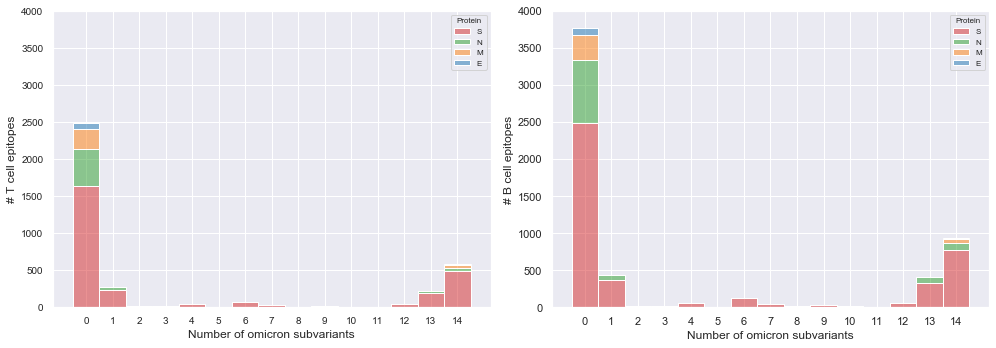

In [29]:
# Distribution od linear epitopes according to the number of varinats affecting them
sns.set(style= "darkgrid")
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig= plt.gca()


sns.histplot(data=tcell_w_var[tcell_w_var['Prot_type']=='ST'].sort_values('Epitope_Molecule Parent'), x= "count_lin_mut", hue="Epitope_Molecule Parent", multiple="stack"
             , alpha=0.5,bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5], ax=axes[0]
            ,palette= 'tab10')
sns.histplot(data=bcell_w_var[bcell_w_var['Prot_type']=='ST'].sort_values('Epitope_Molecule Parent'), x= "count_lin_mut", hue="Epitope_Molecule Parent", multiple="stack"
             , alpha=0.5,bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5], ax=axes[1]
            ,palette= 'tab10')




axes[0].set_xlabel("Number of omicron subvariants")
axes[1].set_xlabel("Number of omicron subvariants")

axes[0].set_xticks(range(15))
axes[1].set_xticks(range(15))

axes[0].set_ylabel("# T cell epitopes")
axes[1].set_ylabel("# B cell epitopes")


axes[0].set(ylim=(0, 4000))
axes[1].set(ylim=(0, 4000))

axes[0].legend(title='Protein', title_fontsize=8, labels=['S', 'N', 'M', 'E'], loc='upper right', fontsize = 8, ncol=1)
axes[1].legend(title='Protein', title_fontsize=8, labels=['S', 'N', 'M', 'E'], loc='upper right', fontsize = 8, ncol=1)

axes[0].tick_params(axis='both', which='major', labelsize=10)
axes[0].tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.show()

# Builiding the coverage matrix

In [30]:
S= list('S'*1273)
N= list('N'*419)
M= list('M'*222)
E=list('E'*75)
ORF1ab= ['ORF1ab']*7096
ORF3a= ['ORF3a']*275
ORF8= ['ORF8']*121
ORF7a= ['ORF7a']*121
ORF6= ['ORF6']*61
ORF10= ['ORF10']*38
ORF7b= ['ORF7b']*43
ORF1a= ['ORF1a']*4405
ORF9b= ['ORF9b']*97
ORF9c= ['ORF9c']*73
Protein_string=S+ORF1ab+ORF3a+N+M+ORF8+E+ORF7a+ORF6+ORF10+ORF7b+ORF1a+ORF9b+ORF9c

coverage = pd.DataFrame(columns= ["Protein", "Position","Tcell_Epitope_count", "Bcell_Epitope_count"])
coverage['Protein']= Protein_string

for i in range(1,len(coverage)):
    coverage['Position'][0]=1
    if coverage['Protein'][i] == coverage['Protein'][i-1]:
        coverage['Position'][i]= int(coverage['Position'][i-1])+1
    else:
        coverage['Position'][i]=1

for i in range(len(coverage)):
    prot= coverage['Protein'][i]
    pos= coverage['Position'][i]
    
    df_t= tcell_w_var[(tcell_w_var['Epitope_Molecule Parent']==prot) & (tcell_w_var['Epitope_Starting Position']<= pos) & (tcell_w_var['Epitope_Ending Position']>=pos)]
    coverage['Tcell_Epitope_count'][i]= len(df_t) 
    
    df_b= bcell_w_var[(bcell_w_var['Epitope_Molecule Parent']==prot) & (bcell_w_var['Epitope_Starting Position']<= pos) & (bcell_w_var['Epitope_Ending Position']>=pos)]
    coverage['Bcell_Epitope_count'][i]= len(df_b)
coverage_S= coverage[coverage['Protein']=='S']

C:\Users\Asus\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


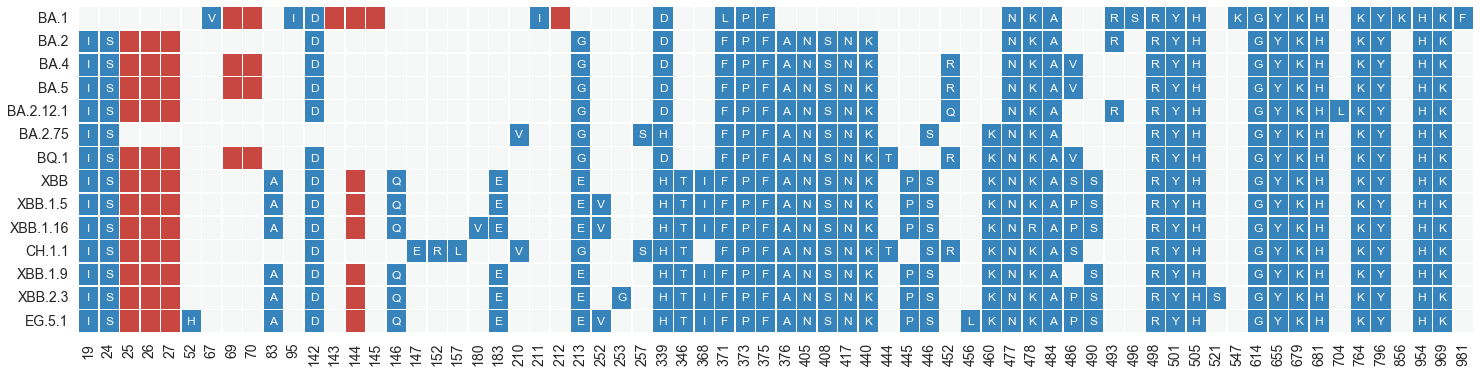

In [31]:
#To visulaize the characterizing mutations of the variants (considering only the Spike protein)
heat_S = pd.DataFrame(index= omicron.columns, columns= coverage_S['Position'].tolist(), data=float(0))

for pos_S in heat_S.columns:
    for var in heat_S.index:
        var_mut= [x for x in omicron[var] if str(x) !='nan']
    
        for mut in var_mut:
            prot= mut.split(':')[0]
            if prot=='S':
                if  mut.split(':')[1][-1].isdigit()==False: 
                    pos= int(mut.split(':')[1][1:-1])
                else:  
                    pos= int(mut.split(':')[1][3:])
                
                if pos==pos_S and mut.split(':')[1][-1].isdigit()==False: 
                    heat_S[pos_S][var]=float(1)
                elif pos==pos_S and mut.split(':')[1][-1].isdigit()==True: 
                    heat_S[pos_S][var]=float(-1)

df_pos = heat_S.loc[(heat_S).any(1), (heat_S!=0).any(0)]                    
df_aa = heat_S.loc[(heat_S).any(1), (heat_S!=0).any(0)]

for var in df_aa.index:
    var_mut= [x for x in omicron[var] if str(x) !='nan']
    pos_list= list()
    for mut in var_mut:
        prot= mut.split(':')[0]
        if prot=='S':
            
            if mut.split(':')[1][0:3]!='del':
                pos= int(mut.split(':')[1][1:-1])
                alt= mut.split(':')[1][-1]
                df_aa[pos][var]=alt
            else:
                pos= int(mut.split(':')[1][3:])
                df_aa[pos][var]='del'

labels=  np.array([df_aa.loc[var] for var in df_aa.index])
for i in labels:
    for j in range(len(i)):
        if i[j]== 0 or i[j]== 'del':
            i[j]=''

img = df_pos.astype(np.float32)
fig, ax = plt.subplots(figsize=(14,6))

custom_palette = sns.color_palette("RdBu",5)
sns.heatmap(img,cmap=custom_palette,annot= labels, linewidth=.5, fmt='', cbar=False)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

fig.set_size_inches(25,6)


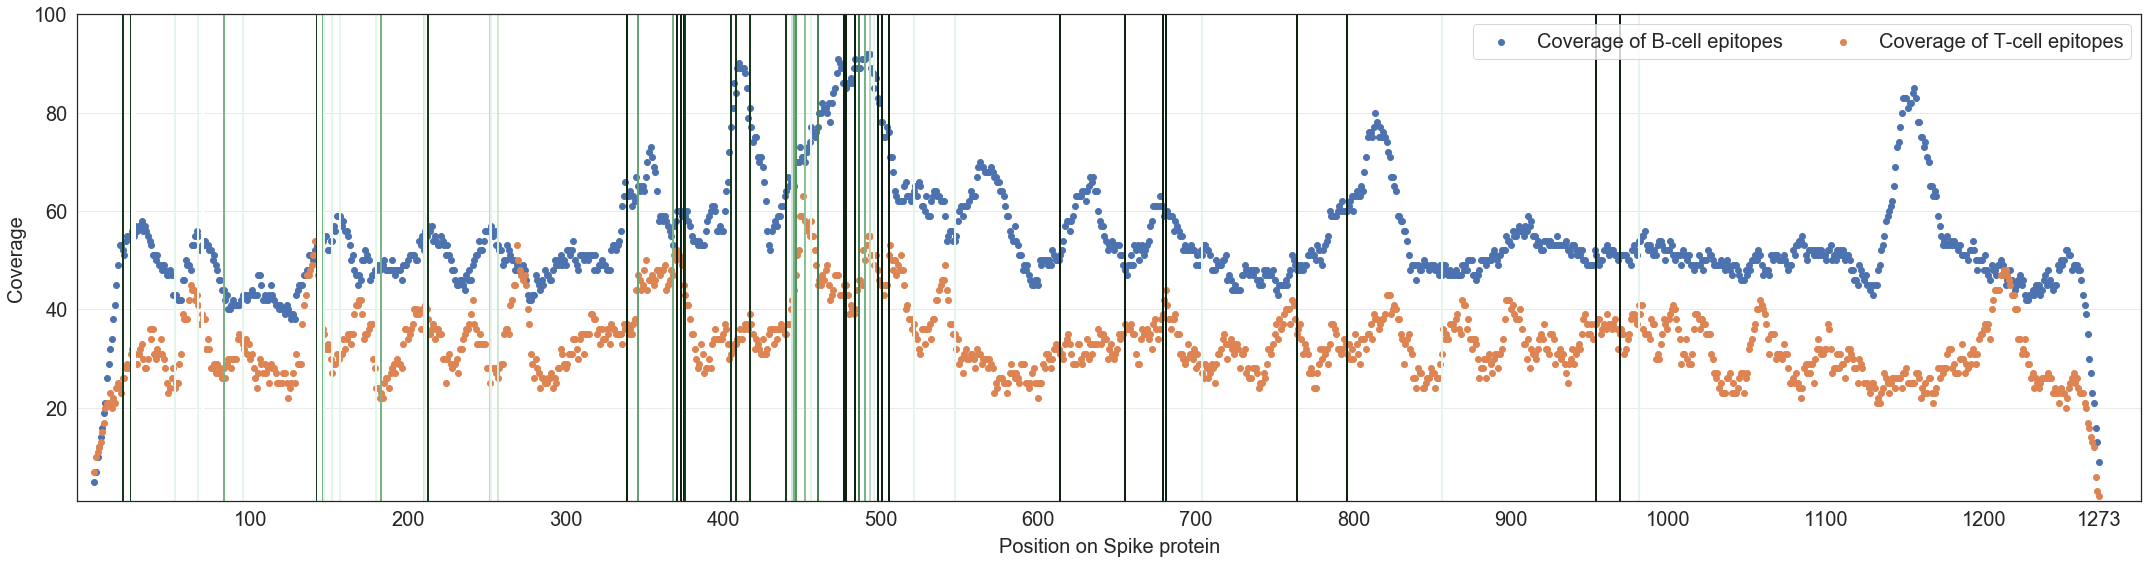

In [32]:
#T cell anf B cell linear epitopes coverage over Spike protein.
#Green vertical lines are used to highlight the postions of mutations.
#The darker the color the higher the number of subvariants with a mutation at that position.

sns.set(style= "white")
fig = plt.figure(linewidth=1, figsize=(7, 5))
ax = plt.gca()

ax.scatter(coverage_S['Position'], coverage_S["Bcell_Epitope_count"], label= "Coverage of B-cell epitopes")
ax.scatter(coverage_S['Position'], coverage_S["Tcell_Epitope_count"], label= "Coverage of T-cell epitopes")

x= [int(i) for i in df_aa.columns]
heat_S.loc['Total']=0
heat_S= heat_S.astype(np.float32)
for i in list(heat_S.columns):
    heat_S.loc['Total'][i]= sum(heat_S[i]>0)


df= pd.DataFrame( columns= heat_S.columns)
df.loc['var']= heat_S.loc['Total']

ax.vlines(x=x,  ymin=0, ymax=100, linewidth=2, color=sns.cubehelix_palette(n_colors=15,start=2, rot=0, dark=0.2, light=1))
palette= sns.cubehelix_palette(n_colors=15,start=2, rot=0, dark=0.1, light=1)
for i in x:
    c=int(df[i][0])
    color= palette[c]
    plt.axvline(x=int(i), ymin=0, ymax=100, linewidth=2, color=color)


ax.set_xlabel("Position on Spike protein", fontsize=20, labelpad=8)
ax.set_ylabel("Coverage", fontsize=20, labelpad=8)

ax.set_xlim(-10, 1300)
ax.set_ylim(1, 100)

plt.xticks((100,200,300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1273), fontsize=20)
plt.yticks(fontsize=20)

plt.grid(axis='y', alpha=.4)

ax.legend(loc='upper right', fontsize = 20, ncol=3)
fig.set_size_inches(30,8)
plt.tight_layout() 
plt.show()

# Coverage statistics per AA per protein

In [33]:
coverage_stats= pd.DataFrame(columns= ["Min. count of Tcell epitopes per AA", "Max. count of Tcell epitopes per AA", "Avr. count Tcell epitopes per AA", "Med. count Tcell epitopes per AA"
                                      ,"Min. count of Bcell epitopes per AA", "Max. count of Bcell epitopes per AA", "Avr. count Bcell epitopes per AA", "Med. count Bcell epitopes per AA"]
                   , index= ['S', 'N', 'M', 'E', 'ORF1ab','ORF1a', 'ORF3a', 'ORF6', 'ORF7a', 'ORF7b', 'ORF8', 'ORF9b','ORF9c','ORF10'])

for i in list(coverage_stats.index):
    coverage_stats["Min. count of Tcell epitopes per AA"][i]= min(coverage[coverage['Protein']==i]['Tcell_Epitope_count'])
    coverage_stats["Max. count of Tcell epitopes per AA"][i]= max(coverage[coverage['Protein']==i]['Tcell_Epitope_count'])
    coverage_stats["Avr. count Tcell epitopes per AA"][i]= statistics.mean(coverage[coverage['Protein']==i]['Tcell_Epitope_count'])
    coverage_stats["Med. count Tcell epitopes per AA"][i]= statistics.median(coverage[coverage['Protein']==i]['Tcell_Epitope_count'])
    coverage_stats["Min. count of Bcell epitopes per AA"][i]= min(coverage[coverage['Protein']==i]['Bcell_Epitope_count'])
    coverage_stats["Max. count of Bcell epitopes per AA"][i]= max(coverage[coverage['Protein']==i]['Bcell_Epitope_count'])
    coverage_stats["Avr. count Bcell epitopes per AA"][i]= statistics.mean(coverage[coverage['Protein']==i]['Bcell_Epitope_count'])
    coverage_stats["Med. count Bcell epitopes per AA"][i]= statistics.median(coverage[coverage['Protein']==i]['Bcell_Epitope_count'])
    
coverage_stats

,Min. count of Tcell epitopes per AA,Max. count of Tcell epitopes per AA,Avr. count Tcell epitopes per AA,Med. count Tcell epitopes per AA,Min. count of Bcell epitopes per AA,Max. count of Bcell epitopes per AA,Avr. count Bcell epitopes per AA,Med. count Bcell epitopes per AA
S,2,63,33.116261,32,5,92,54.344855,52
N,4,34,19.527446,18,9,56,42.212411,42
M,3,38,20.283784,20.0,7,35,28.414414,29.0
E,3,25,14.68,15,5,33,25.813333,29
ORF1ab,0,18,2.692644,2.0,2,44,29.075958,29.0
ORF1a,0,3,0.024972,0,0,8,0.026788,0
ORF3a,3,18,8.476364,8,3,37,25.956364,25
ORF6,0,14,6.590164,6,2,30,21.590164,25
ORF7a,1,15,7.454545,7,3,36,25.603306,27
ORF7b,0,4,2.395349,3,2,18,12.72093,15


# Comparing with previous VOCs

In [34]:
#Here I added previously designated VOCs -> Alpha: B.1.1.7, Beta: B.1.351, Delta: B.1.617.2, and Gamma: P.1
variant= pd.read_excel('variants.xlsx')
added_columns=variant.columns.tolist()+list([i+'_count' for i in variant.columns])+list(["count_other_lin_mut"])
tcell_w_var=pd.concat([tcell_w_var,pd.DataFrame(columns=added_columns)])
bcell_w_var=pd.concat([bcell_w_var,pd.DataFrame(columns=added_columns)])
var_all=pd.concat([omicron,variant])

In [35]:
#Reapting the same calculations on previous VOCs

for var in variant.columns:
    tcell_w_var.loc[tcell_w_var[var].isnull(),[var]] = tcell_w_var.loc[tcell_w_var[var].isnull(),var].apply(lambda x: [])
    bcell_w_var.loc[bcell_w_var[var].isnull(),[var]] = bcell_w_var.loc[bcell_w_var[var].isnull(),var].apply(lambda x: [])
    var_mut= [x for x in variant[var] if str(x) !='nan']

    for mut in var_mut:
        prot= mut.split(':')[0]
        

        if mut.split(':')[1][-1].isdigit()==False: 
            pos= int(mut.split(':')[1][1:-1])
        else:   
            pos= int(mut.split(':')[1][3:])

        df= tcell_w_var[(tcell_w_var['Epitope_Molecule Parent']==prot) & (tcell_w_var['Epitope_Starting Position']<= pos) & (tcell_w_var['Epitope_Ending Position']>=pos)]
        df.index= range(len(df))

        for i in range(len(df)):
            epi= df['Epitope_Name'][i]
            start= df["Epitope_Starting Position"][i]
            end= df["Epitope_Ending Position"][i]
            
            if mut[-1].isdigit()==False and epi[int(pos-start)]!= mut[-1]:   
                df[var][i].append(mut)
                
            if mut[-1].isdigit(): 
                df[var][i].append(mut)
                
        df_b= bcell_w_var[(bcell_w_var['Epitope_Molecule Parent']==prot) & (bcell_w_var['Epitope_Starting Position']<= pos) & (bcell_w_var['Epitope_Ending Position']>=pos)]
        df_b.index= range(len(df_b))

        for j in range(len(df_b)):
            epi= df_b['Epitope_Name'][j]
            start= df_b["Epitope_Starting Position"][j]
            end= df_b["Epitope_Ending Position"][j]
            
            if mut[-1].isdigit()==False and epi[int(pos-start)]!= mut[-1]:   
                df_b[var][j].append(mut)
                
            if mut[-1].isdigit(): 
                df_b[var][j].append(mut)
    
print('Mapping the characterizing mutations of previous VOCs over the T cell and B cell linear epitopes is done')

for var in variant.columns:
    var_count= var+'_count'
    for i in range(len(tcell_w_var)):
        tcell_w_var[var_count][i] = len(tcell_w_var[var][i]) 

    for j in range(len(bcell_w_var)):
        bcell_w_var[var_count][j] = len(bcell_w_var[var][j])

print('Counting the characterizing mutations of previous VOCs over the T cell and B cell linear epitopes is done') 

Mapping the characterizing mutations of previous VOCs over the T cell and B cell linear epitopes is done


C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Counting the characterizing mutations of previous VOCs over the T cell and B cell linear epitopes is done


In [36]:
#To count how many characterizing mutations (of previous VOCs) affecting an epitopes
for i in range(len(tcell_w_var)):
    tcell_w_var["count_other_lin_mut"][i]= len([k for k in list(tcell_w_var.iloc[i])[39:43] if k>0])
for j in range(len(bcell_w_var)):
    bcell_w_var["count_other_lin_mut"][j]= len([k for k in list(bcell_w_var.iloc[j])[39:43] if k>0])


C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [37]:
table = pd.DataFrame(columns= ["# Mutations on Spike", "# T cell epitopes", "% T cell epitopes", "# B cell epitopes", "% B cell epitopes"]
                     , index= var_all.columns)

for i in list(table.index):
    table["# Mutations on Spike"][i]= len([m for m in var_all[i]  if str(m) !='nan' and m[0]=='S'])
    table["# T cell epitopes"][i]= sum(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']=='S'][i+'_count']>0)
    table["% T cell epitopes"][i]= sum(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']=='S'][i+'_count']>0)/len(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']=='S'])*100
    table["# B cell epitopes"][i]= sum(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']=='S'][i+'_count']>0)
    table["% B cell epitopes"][i]= sum(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']=='S'][i+'_count']>0)/len(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']=='S'])*100
table

,# Mutations on Spike,# T cell epitopes,% T cell epitopes,# B cell epitopes,% B cell epitopes
BA.1,33,731,26.163207,1095,25.329632
BA.2,31,695,24.874732,1116,25.815406
BA.4,34,776,27.773801,1220,28.221143
BA.5,34,776,27.773801,1220,28.221143
BA.2.12.1,33,771,27.594846,1216,28.128614
BA.2.75,30,722,25.841088,1189,27.504048
BQ.1,36,791,28.310666,1253,28.984502
XBB,41,838,29.992842,1339,30.973861
XBB.1.5,42,863,30.887616,1395,32.269257
XBB.1.16,43,870,31.138153,1403,32.454314


In [38]:
table = pd.DataFrame(columns= ["Tcell: Count", "Tcell: Min length", "Tcell: Max length", "Tcell: Average length",
                               "Bcell: Count", "Bcell: Min length", "Bcell: Max length", "Bcell: Average length"]
                   , index= ['S', 'N', 'M', 'E', 'ORF1ab','ORF1a', 'ORF3a', 'ORF6', 'ORF7a', 'ORF7b', 'ORF8', 'ORF9b','ORF9c','ORF10'])


for i in list(table.index):
    table["Tcell: Count"][i]= len(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']==i])
    table["Tcell: Min length"][i]= min(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']==i]['length'])
    table["Tcell: Max length"][i]= max(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']==i]['length'])
    table["Tcell: Average length"][i]= statistics.mean(tcell_w_var[tcell_w_var['Epitope_Molecule Parent']==i]['length'])

    if i != 'ORF9c':
        table["Bcell: Count"][i]= len(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']==i])
        table["Bcell: Min length"][i]= min(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']==i]['length'])
        table["Bcell: Max length"][i]= max(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']==i]['length'])
        table["Bcell: Average length"][i]= statistics.mean(bcell_w_var[bcell_w_var['Epitope_Molecule Parent']==i]['length'])
    
table

,Tcell: Count,Tcell: Min length,Tcell: Max length,Tcell: Average length,Bcell: Count,Bcell: Min length,Bcell: Max length,Bcell: Average length
S,2794,7,43,15.171797,4323,4,48,16.047421
N,603,7,38,13.945274,1101,4,47,16.138965
M,326,8,41,13.898773,397,10,32,15.889169
E,86,8,21,12.802326,123,10,23,15.739837
ORF1ab,1716,8,29,11.20338,13325,11,48,15.484953
ORF1a,8,13,15,13.75,8,12,16,14.75
ORF3a,171,5,38,13.631579,466,7,34,15.317597
ORF6,29,9,31,13.862069,87,11,16,15.137931
ORF7a,69,8,35,13.202899,206,11,17,15.038835
ORF7b,9,8,25,11.444444,35,12,16,15.628571


# Using Metadata with focusing only on the Spike protein

In [39]:
tcell_lin = tcell_sars2[tcell_sars2["Epitope_Object Type"]== "Linear peptide"]
bcell_lin = bcell_sars2[bcell_sars2["Epitope_Object Type"]== "Linear peptide"]

tcell_s= tcell_lin[tcell_lin['Epitope_Molecule Parent']=='Spike glycoprotein'][["Epitope_IEDB IRI", "Epitope_Name", "Epitope_Starting Position", "Epitope_Ending Position",
                     "Reference_IEDB IRI", "Assay_Qualitative Measurement", "Assay_Number of Subjects Tested", "Assay_Number of Subjects Positive"]]
bcell_s= bcell_lin[bcell_lin['Epitope_Molecule Parent']=='Spike glycoprotein'][["Epitope_IEDB IRI", "Epitope_Name", "Epitope_Starting Position", "Epitope_Ending Position",
                     "Reference_IEDB IRI", "Assay_Qualitative Measure", "Assay_Number of Subjects Tested", "Assay_Number of Subjects Positive"]]
bcell_s.columns= tcell_s.columns
tcell_s.index= range(len(tcell_s))
bcell_s.index= range(len(bcell_s))

tcell_s['Cell']='Tcell'
bcell_s['Cell']='Bcell'

All_lin_epi= pd.concat([tcell_s,bcell_s])
All_lin_epi.index= range(len(All_lin_epi))


print('Tcell linear epitopes Spike entries:',len(tcell_s))
print('Bcell linear epitopes Spike entries:',len(bcell_s))

Tcell linear epitopes Spike entries: 12415
Bcell linear epitopes Spike entries: 20848


In [40]:
#Filling the missing information of the Number of Subjects following IEDB documentaitons 
for i in range(len(tcell_s)):
    if np.isnan(tcell_s['Assay_Number of Subjects Tested'][i]) and tcell_s['Assay_Qualitative Measurement'][i]!='Negative':
        tcell_s['Assay_Number of Subjects Tested'][i]= 1
        tcell_s['Assay_Number of Subjects Positive'][i]= 1
    
    elif np.isnan(tcell_s['Assay_Number of Subjects Tested'][i]) and tcell_s['Assay_Qualitative Measurement'][i]=='Negative':
        tcell_s['Assay_Number of Subjects Tested'][i]= 1
        tcell_s['Assay_Number of Subjects Positive'][i]= 0
    
    if np.isnan(tcell_s['Assay_Number of Subjects Positive'][i]) and tcell_s['Assay_Qualitative Measurement'][i]!='Negative':
        tcell_s['Assay_Number of Subjects Positive'][i]= 1
    
    elif np.isnan(tcell_s['Assay_Number of Subjects Positive'][i]) and tcell_s['Assay_Qualitative Measurement'][i]=='Negative':
        tcell_s['Assay_Number of Subjects Positive'][i]= 0
    
    
for i in range(len(bcell_s)):
    if np.isnan(bcell_s['Assay_Number of Subjects Tested'][i]) and bcell_s['Assay_Qualitative Measurement'][i]!='Negative':
        bcell_s['Assay_Number of Subjects Tested'][i]= 1
        bcell_s['Assay_Number of Subjects Positive'][i]= 1
    
    elif np.isnan(bcell_s['Assay_Number of Subjects Tested'][i]) and bcell_s['Assay_Qualitative Measurement'][i]=='Negative':
        bcell_s['Assay_Number of Subjects Tested'][i]= 1
        bcell_s['Assay_Number of Subjects Positive'][i]= 0
        
    if np.isnan(bcell_s['Assay_Number of Subjects Positive'][i]) and bcell_s['Assay_Qualitative Measurement'][i]!='Negative':
        bcell_s['Assay_Number of Subjects Positive'][i]= 1
    
    elif np.isnan(bcell_s['Assay_Number of Subjects Positive'][i]) and bcell_s['Assay_Qualitative Measurement'][i]=='Negative':
        bcell_s['Assay_Number of Subjects Positive'][i]= 0

print('Filling the missing Numbers of Subjects')

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launc

Filling the missing Numbers of Subjects


In [41]:
added_columns=list(['Subjects_Tested'])+list(['Subjects_Responded'])+list(['Positive_Assay'])+list(['Negative_Assay'])+list(['Response_Frequnecy'])+list(['95 CI lower'])+list(['95 CI upper'])
epi_stat= pd.concat([All_lin_epi[["Cell", "Epitope_IEDB IRI","Epitope_Name", "Epitope_Starting Position", "Epitope_Ending Position"]],pd.DataFrame(columns=added_columns)])

epi_stat= epi_stat.drop_duplicates()
epi_stat.index= range(len(epi_stat))


for i in range(len(epi_stat)):
    count_pos= 0
    count_neg= 0
    
    count_sub_tested= 0
    count_sub_pos= 0
    epi = epi_stat["Epitope_Name"][i]
    
    if epi_stat['Cell'][i]=='Tcell':
        df= tcell_s[tcell_s['Epitope_Name']== epi]
        assay = df['Reference_IEDB IRI'].unique()
        for j in assay:
            df2=df[df['Reference_IEDB IRI']== j]
            measure= df2['Assay_Qualitative Measurement'].unique()
            if len(measure)== 1:
                if measure!='Negative':
                    count_pos +=1

                if measure== 'Negative':
                    count_neg +=1

                count_sub_tested= count_sub_tested + max(df2['Assay_Number of Subjects Tested'])
                count_sub_pos= count_sub_pos + max(df2[df2['Assay_Number of Subjects Tested']==max(df2['Assay_Number of Subjects Tested'])]['Assay_Number of Subjects Positive'])

            if len(measure)> 1:
                count_pos +=1  
                df3= df2[df2['Assay_Qualitative Measurement']!= 'Negative']
                count_sub_tested= count_sub_tested + max(df3['Assay_Number of Subjects Tested'])
                count_sub_pos= count_sub_pos + max(df3[df3['Assay_Number of Subjects Tested']==max(df3['Assay_Number of Subjects Tested'])]['Assay_Number of Subjects Positive'])
    
    
    else:
        df= bcell_s[bcell_s['Epitope_Name']== epi]
        assay = df['Reference_IEDB IRI'].unique()
        for j in assay:
            df2=df[df['Reference_IEDB IRI']== j]
            measure= df2['Assay_Qualitative Measurement'].unique()
            if len(measure)== 1:
                if measure!='Negative':
                    count_pos +=1

                if measure== 'Negative':
                    count_neg +=1

                count_sub_tested= count_sub_tested + max(df2['Assay_Number of Subjects Tested'])
                count_sub_pos= count_sub_pos + max(df2[df2['Assay_Number of Subjects Tested']==max(df2['Assay_Number of Subjects Tested'])]['Assay_Number of Subjects Positive'])

            if len(measure)> 1:
                count_pos +=1  
                df3= df2[df2['Assay_Qualitative Measurement']!= 'Negative']
                count_sub_tested= count_sub_tested + max(df3['Assay_Number of Subjects Tested'])
                count_sub_pos= count_sub_pos + max(df3[df3['Assay_Number of Subjects Tested']==max(df3['Assay_Number of Subjects Tested'])]['Assay_Number of Subjects Positive'])

    
    epi_stat['Positive_Assay'][i]= count_pos
    epi_stat['Negative_Assay'][i]= count_neg
    epi_stat['Subjects_Tested'][i]= count_sub_tested
    epi_stat['Subjects_Responded'][i]= count_sub_pos
    
    
    
    #for calculating the CI:
    n = epi_stat['Subjects_Tested'][i] 
    x = epi_stat['Subjects_Responded'][i] 
    p_hat = x / n
    confidence_level = 0.95
    standard_error = math.sqrt((p_hat * (1 - p_hat)) / n)
    margin_of_error= 1.96 * standard_error #for 95% CI

    # Calculate the lower and upper bounds of the confidence interval
    lower_bound = p_hat - margin_of_error
    upper_bound = p_hat + margin_of_error
    
        
    if lower_bound < 0:
        lower_bound=0
    if upper_bound > 1:
        upper_bound=1
        
    epi_stat['Response_Frequnecy'][i]= p_hat
    epi_stat['95 CI lower'][i]= lower_bound
    epi_stat['95 CI upper'][i]= upper_bound

print('The counts of positive and negative assays per epitope are calculated')    
print('The values of RF and 95% CI per epitope are calculated')

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:65: SettingWithCopyWarning: 
A value is

The counts of positive and negative assays per epitope are calculated
The values of RF and 95% CI per epitope are calculated


In [42]:
coverage = pd.DataFrame(columns= ["Protein", "Position","Tcell_Positive_Assay", "Tcell_Negative_Assay","Tcell_pos_percentage", "Bcell_Positive_Assay", "Bcell_Negative_Assay", "Bcell_pos_percentage"])
coverage['Protein']= list('S'*1273)
coverage['Position']= range(1,1274)

RF = pd.DataFrame(columns= ["Protein", "Position","Tcell_RF", "Tcell_lower_95CI", "Tcell_upper_95CI", "Bcell_RF", "Bcell_lower_95CI", "Bcell_upper_95CI"])
RF['Protein']= list('S'*1273)
RF['Position']= range(1,1274)

for i in range(len(coverage)):
    pos= coverage['Position'][i]
    
    df_t= epi_stat[(epi_stat['Cell']=='Tcell') & (epi_stat['Epitope_Starting Position']<= pos) & (epi_stat['Epitope_Ending Position']>=pos)]
    coverage['Tcell_Positive_Assay'][i]= sum(df_t['Positive_Assay']) 
    coverage['Tcell_Negative_Assay'][i]= sum(df_t['Negative_Assay']) 
    coverage['Tcell_pos_percentage'][i]= coverage["Tcell_Positive_Assay"][i]*100/(coverage["Tcell_Positive_Assay"][i]+coverage["Tcell_Negative_Assay"][i])

    RF['Tcell_RF'][i]= mean(df_t['Response_Frequnecy'])
    RF['Tcell_lower_95CI'][i]= mean(df_t['95 CI lower'])
    RF['Tcell_upper_95CI'][i]= mean(df_t['95 CI upper'])

    df_b= epi_stat[(epi_stat['Cell']=='Bcell') & (epi_stat['Epitope_Starting Position']<= pos) & (epi_stat['Epitope_Ending Position']>=pos)]
    coverage['Bcell_Positive_Assay'][i]= sum(df_b['Positive_Assay']) 
    coverage['Bcell_Negative_Assay'][i]= sum(df_b['Negative_Assay']) 
    coverage['Bcell_pos_percentage'][i]= coverage["Bcell_Positive_Assay"][i]*100/(coverage["Bcell_Positive_Assay"][i]+coverage["Bcell_Negative_Assay"][i])
    
    RF['Bcell_RF'][i]= mean(df_b['Response_Frequnecy'])
    RF['Bcell_lower_95CI'][i]= mean(df_b['95 CI lower'])
    RF['Bcell_upper_95CI'][i]= mean(df_b['95 CI upper'])
    
print("The sum of assays per AA of the Spike is calculated.")
print("The average RF per AA of the Spike is calculated.")

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
C:\Users\Asus\anaconda3\lib\site-packages

The sum of assays per AA of the Spike is calculated.
The average RF per AA of the Spike is calculated.


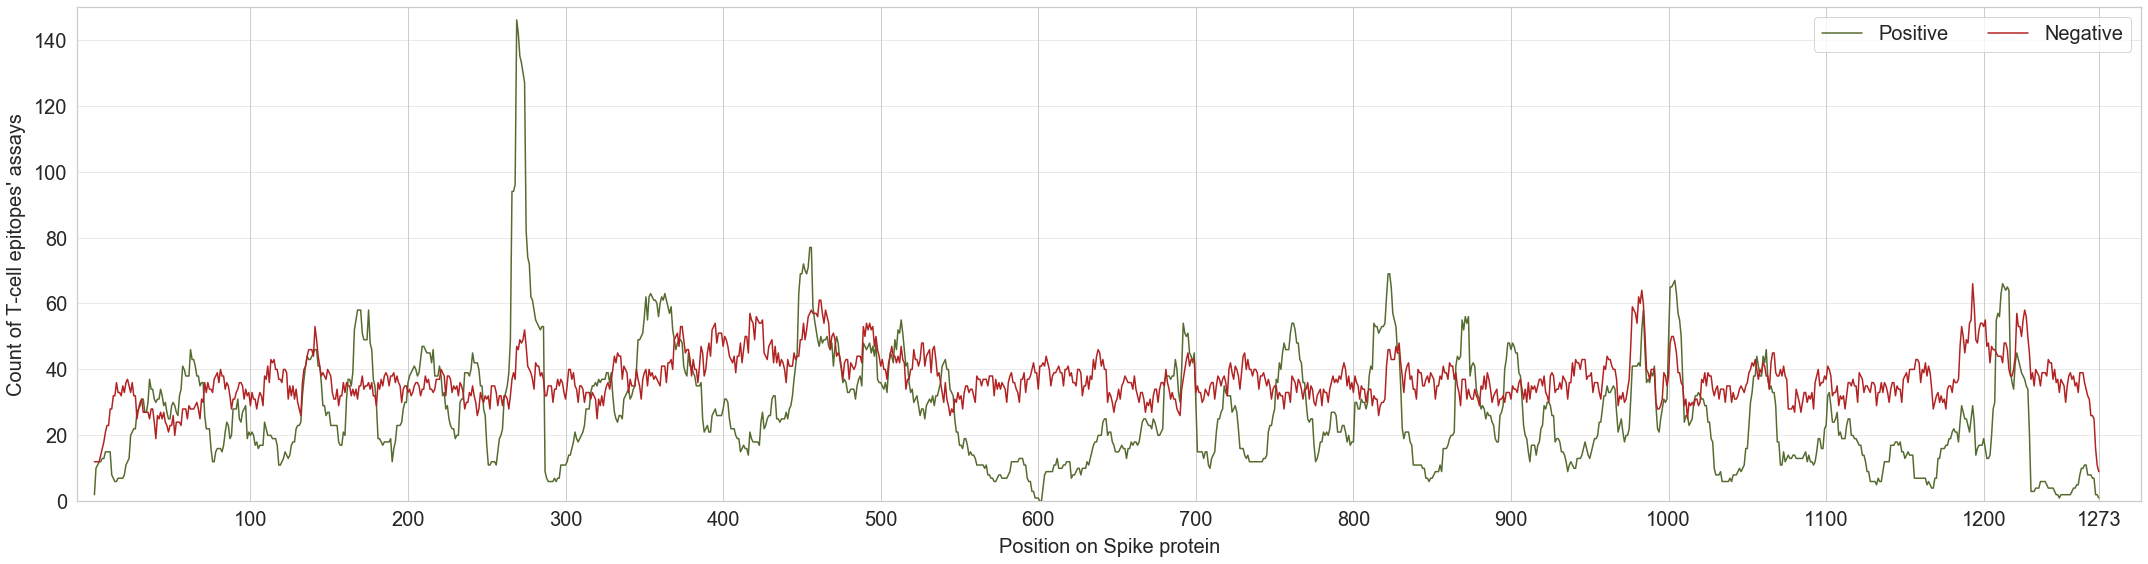

In [43]:
sns.set(style= "whitegrid")
fig = plt.figure(linewidth=1, figsize=(7, 5))
ax = plt.gca()

ax.plot(coverage['Position'], coverage["Tcell_Positive_Assay"], label= "Positive",color='darkolivegreen')#, drawstyle="steps-post") # <- drawstyle argument.
ax.plot(coverage['Position'], coverage["Tcell_Negative_Assay"], label= "Negative",color='firebrick')#, drawstyle="steps-post") # <- drawstyle argument.


ax.set_xlabel("Position on Spike protein", fontsize=20, labelpad=8)
ax.set_ylabel("Count of T-cell epitopes' assays", fontsize=20, labelpad=8)

ax.set_xlim(-10, 1300)
ax.set_ylim(0, 150)

plt.xticks((100,200,300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1273), fontsize=20)
plt.yticks((0,20,40,60,80, 100,120,140), fontsize=20)

plt.grid(axis='y', alpha=.4)
ax.legend(loc='upper right', fontsize = 20, ncol=3)
fig.set_size_inches(30,8)
plt.tight_layout()

plt.show()

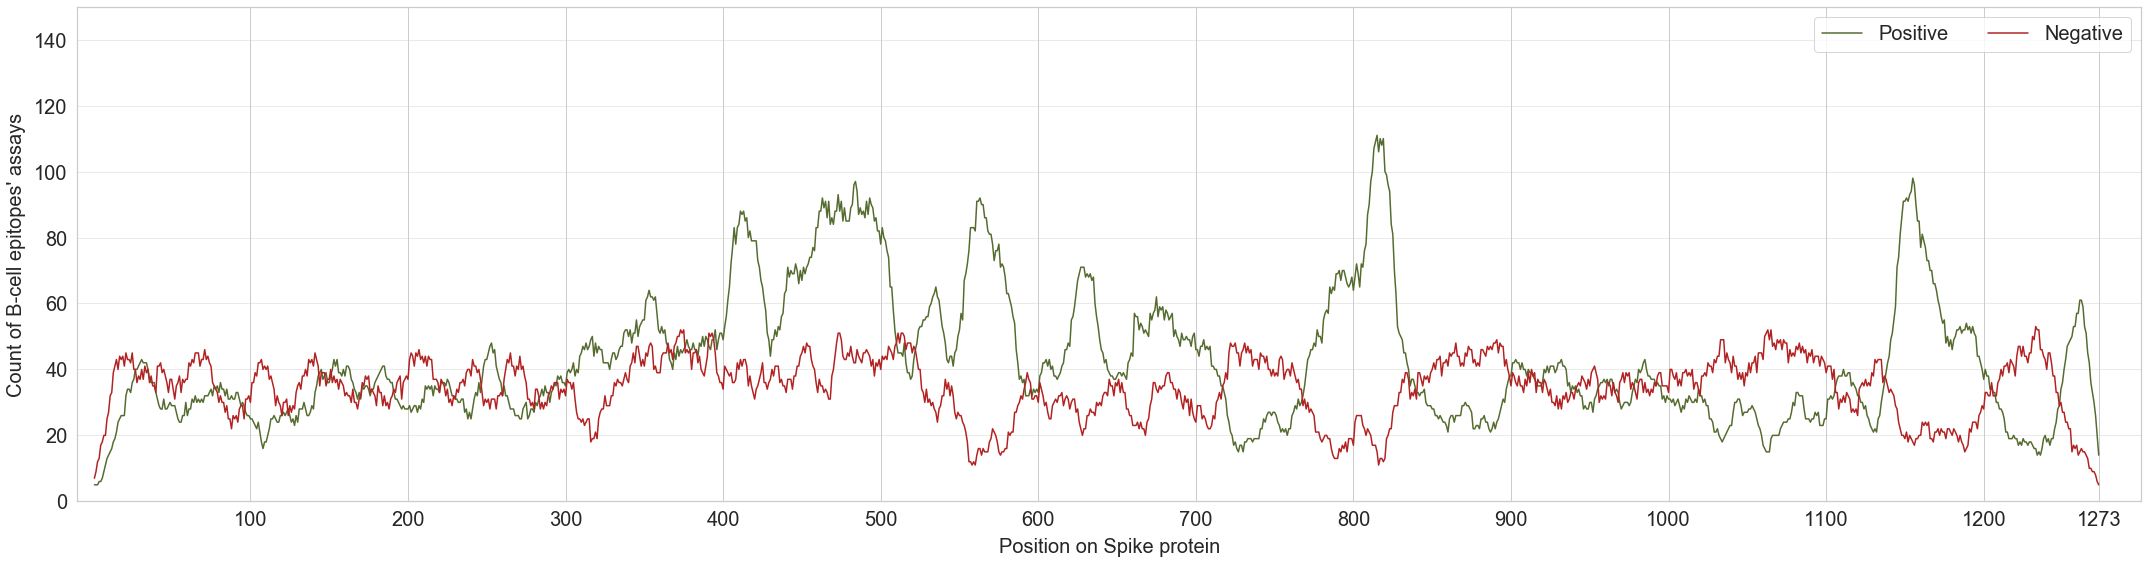

In [44]:
sns.set(style= "whitegrid")
fig = plt.figure(linewidth=1, figsize=(7, 5))
ax = plt.gca()

ax.plot(coverage['Position'], coverage["Bcell_Positive_Assay"], label= "Positive",color='darkolivegreen')
ax.plot(coverage['Position'], coverage["Bcell_Negative_Assay"], label= "Negative",color='firebrick')


ax.set_xlabel("Position on Spike protein", fontsize=20, labelpad=8)
ax.set_ylabel("Count of B-cell epitopes' assays", fontsize=20, labelpad=8)

ax.set_xlim(-10, 1300)
ax.set_ylim(0, 150)

plt.xticks((100,200,300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1273), fontsize=20)
plt.yticks((0,20,40,60,80, 100,120,140), fontsize=20)

plt.grid(axis='y', alpha=.4)
ax.legend(loc='upper right', fontsize = 20, ncol=3)
fig.set_size_inches(30,8)
plt.tight_layout()
plt.show()

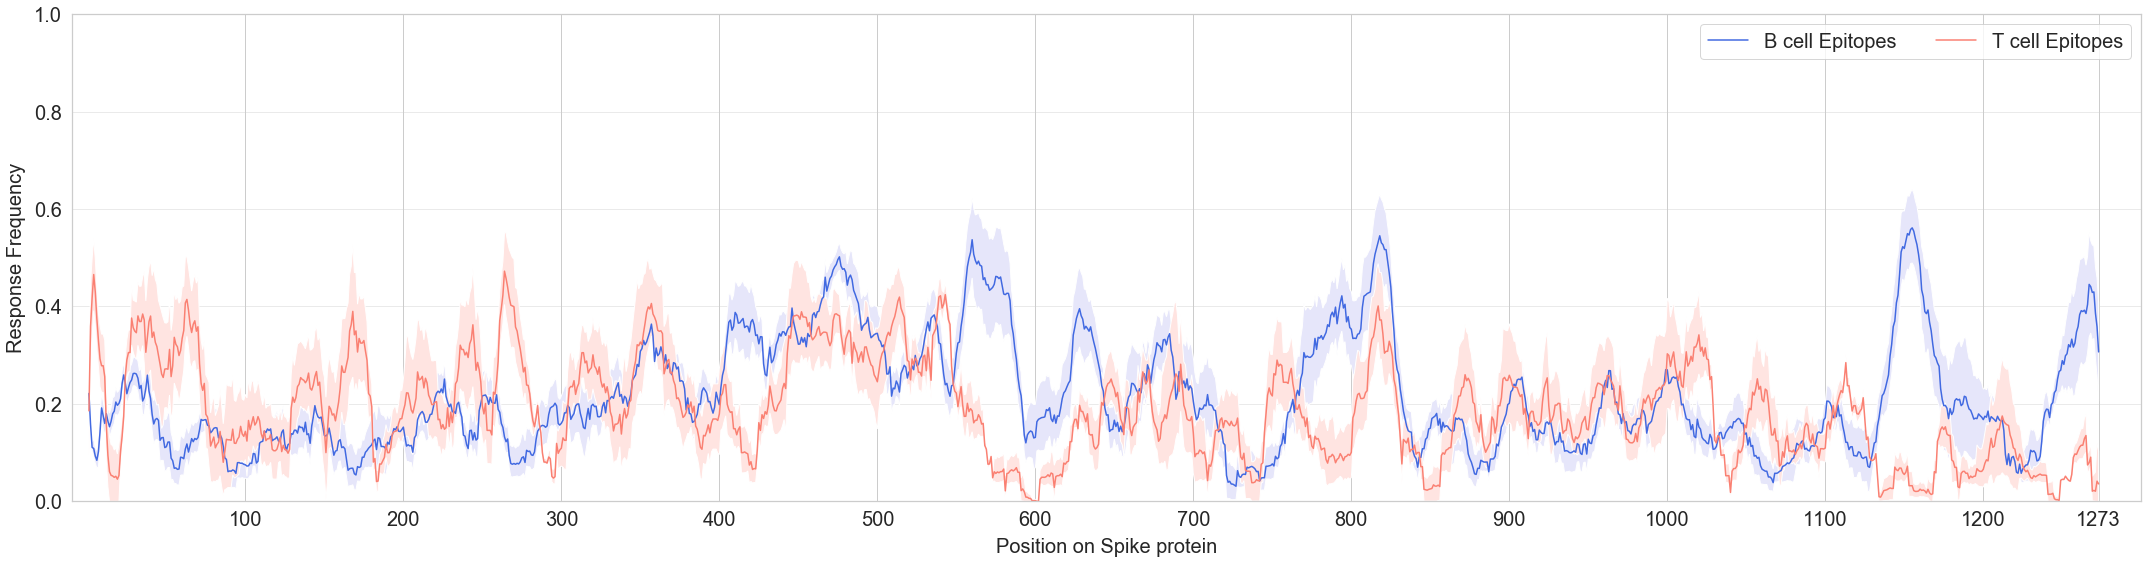

In [45]:
sns.set(style= "whitegrid")
fig = plt.figure(linewidth=1, figsize=(7, 5))
ax = plt.gca()

ax.plot(RF['Position'], RF["Bcell_RF"], color='royalblue', label= 'B cell Epitopes')
plt.fill(np.append(RF['Position'], RF['Position'][::-1]), np.append(RF["Bcell_lower_95CI"], RF["Bcell_upper_95CI"][::-1]), 'lavender')



ax.plot(RF['Position'], RF["Tcell_RF"], color= 'salmon', label= 'T cell Epitopes')
plt.fill(np.append(RF['Position'], RF['Position'][::-1]), np.append(RF["Tcell_lower_95CI"], RF["Tcell_upper_95CI"][::-1]), 'mistyrose')

ax.set_xlabel("Position on Spike protein", fontsize=20, labelpad=8)
ax.set_ylabel("Response Frequency", fontsize=20, labelpad=8)


ax.set_xlim(-10, 1300)
ax.set_ylim(0, 1)

plt.xticks((100,200,300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1273), fontsize=20)
plt.yticks((0,0.2,0.4,0.6,0.8, 1), fontsize=20)

plt.grid(axis='y', alpha=.4)

ax.legend(loc='upper right', fontsize = 20, ncol=3)
fig.set_size_inches(30,8)

plt.tight_layout()
plt.show()

# Monte Carlo approach (Only on Spike linear epitopes)

In [46]:
tcell_w_var['factor']=''
bcell_w_var['factor']=''


for i in range(len(tcell_w_var)):
    factor_list=[]
    for j in omicron.columns:
        j= j+'_count'
        factor_list.append(tcell_w_var[j][i]/tcell_w_var['length'][i])
    
    tcell_w_var['factor'][i]=sum(factor_list)
    
for i in range(len(bcell_w_var)):
    factor_list=[]
    for j in omicron.columns:
        j= j+'_count'
        factor_list.append(bcell_w_var[j][i]/bcell_w_var['length'][i])
    
    bcell_w_var['factor'][i]=sum(factor_list)

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [48]:
t_epi= tcell_w_var[tcell_w_var['Epitope_Molecule Parent']=='S']
b_epi= bcell_w_var[bcell_w_var['Epitope_Molecule Parent']=='S']

t_epi.index=range(len(t_epi))
b_epi.index=range(len(b_epi))

### NOTE: Running the next cell is very time consuming; also, it icludes the random re-positionning of the epitopes. Therefore, I did not run it and I upload the files that have been used in generating the figures of the manuscript

In [ ]:
df_t= pd.DataFrame(index=range(0,1000), columns=['All_count_var', 'factor_var_over_len','var_count','var_hit_count','factor'])
df_b= pd.DataFrame(index=range(0,1000), columns=['All_count_var', 'factor_var_over_len','var_count','var_hit_count','factor'])

for k in range(0,1000):
    All_count_var=[]
    factor_var_over_len=[]
    for i in range(len(t_epi)):
        start= random.randint(1,1273-t_epi['length'][i]+1)
        df= heat_S.iloc[:, start-1:int(start + t_epi['length'][i]-1)] #this is a splicer from spike heat map\n",

        var_list= df.apply(lambda row: sum(row>0), axis=1).tolist()
        factor_len= [j/t_epi['length'][i] for j in var_list] #here I divided the number of var at a position over the len of epitopes
        
        All_count_var.append(var_list)
        factor_var_over_len.append(factor_len)
    df_t['All_count_var'][k]= All_count_var #for the naieve scenario
    df_t['factor_var_over_len'][k]= factor_var_over_len     #for the weighted scenario
    
    All_count_var=[]
    factor_var_over_len=[]

    for i in range(len(b_epi)):
        start= random.randint(1,1273-b_epi['length'][i]+1)
        df= heat_S.iloc[:, start-1:int(start + b_epi['length'][i]-1)]

        var_list= df.apply(lambda row: sum(row>0), axis=1).tolist()
        factor_len= [j/b_epi['length'][i] for j in var_list]
        
        
        All_count_var.append(var_list)
        factor_var_over_len.append(factor_len)
        
  
    df_b['All_count_var'][k]= All_count_var
    df_b['factor_var_over_len'][k]= factor_var_over_len 
     
print('Random repositioning of epitopes for 1k times is done')

for i in range(0,1000):
    var_count=[]
    factor=[]
    for j in df_t['All_count_var'][i]:
        var_count.append(len(list(filter(lambda num: num != 0, j))))
    for k in df_t['factor_var_over_len'][i]:
        factor.append(sum(k))
    
    df_t['var_count'][i]= var_count
    df_t['var_hit_count'][i]= len(list(filter(lambda num: num != 0, df_t['var_count'][i])))
    df_t['factor'][i]= sum(factor)
    
    var_count=[]
    factor=[]
    for l in df_b['All_count_var'][i]:
        var_count.append(len(list(filter(lambda num: num != 0, l))))
    for m in df_b['factor_var_over_len'][i]:
        factor.append(sum(m))
    
    df_b['var_count'][i]= var_count
    df_b['var_hit_count'][i]= len(list(filter(lambda num: num != 0, df_b['var_count'][i])))
    df_b['factor'][i]= sum(factor)

print('Counting and calculating are done')

In [50]:
#Since this approach is randomized, I uploaded the results that we obtained for the visualization
df_t_all=pd.read_csv('new_approach_monte_carlo_Tcell_spike_linear_epitope_repositioning_1K_times_with_counts.csv', index_col=0)
df_b_all= pd.read_csv('new_approach_monte_carlo_Bcell_spike_linear_epitope_repositioning_1K_times_with_counts.csv', index_col=0)

## Visualizing the MC results following the naive scenario

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


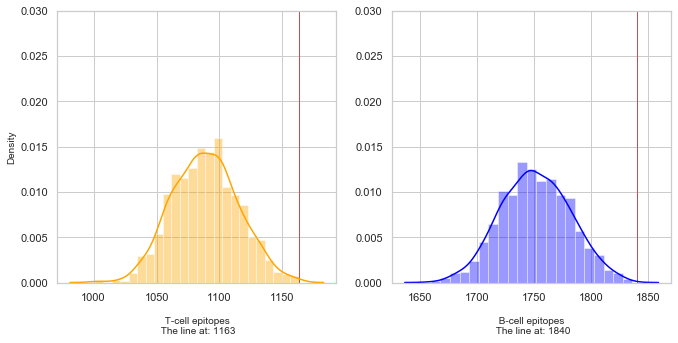

In [79]:
sns.set(style= "whitegrid")
fig, axes = plt.subplots(1,2, figsize=(11, 5))
fig= plt.gcf()

sns.distplot(df_t_all['var_hit_count'], color= 'orange', ax=axes[0])
sns.distplot(df_b_all['var_hit_count'], color='blue', ax=axes[1])

#fig.suptitle(' Counts of Spike linear epitopes affected by at least one omicron subvariant', fontsize=12)
x1= len([k for k in t_epi['count_lin_mut'] if k>0])
x2= len([k for k in b_epi['count_lin_mut'] if k>0])

 
axes[0].set_xlabel(('\n T-cell epitopes \n The line at: '+ str(x1)), fontsize=10)
axes[1].set_xlabel(('\n B-cell epitopes \n The line at: '+ str(x2)), fontsize=10)

axes[0].vlines(x= x1, ymin=0, ymax=0.075, linewidth=1, color='r')
axes[1].vlines(x= x2, ymin=0, ymax=0.075, linewidth=1, color='r')

axes[0].set_ylabel("Density", fontsize=10)
axes[1].set_ylabel("\n", fontsize=10)


axes[0].set(ylim=(0, 0.03))
axes[1].set(ylim=(0, 0.03))

plt.show()

## Visualizing the weighted scenario

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


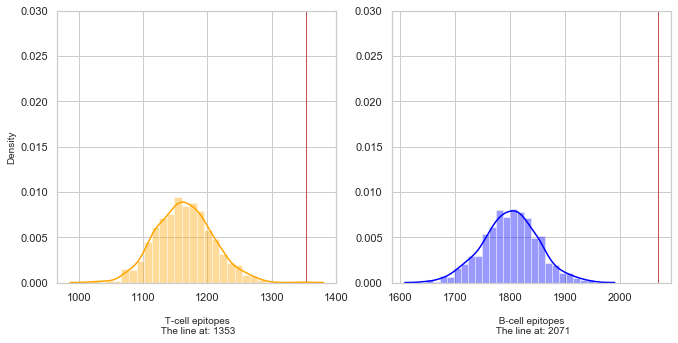

In [83]:
sns.set(style= "whitegrid")
fig, axes = plt.subplots(1,2, figsize=(11, 5))
fig= plt.gcf()

sns.distplot(df_t_all['factor'], color= 'orange', ax=axes[0])
sns.distplot(df_b_all['factor'], color='blue', ax=axes[1])

#fig.suptitle(' Counts of Spike linear epitopes affected by at least one omicron subvariant', fontsize=12)

x1= int(sum(t_epi['factor']))
x2= int(sum(b_epi['factor']))

axes[0].set_xlabel(('\n T-cell epitopes \n The line at: '+ str(x1)), fontsize=10)#, labelpad=8)
axes[1].set_xlabel(('\n B-cell epitopes \n The line at: '+ str(x2)), fontsize=10)#, labelpad=8)

axes[0].vlines(x= x1, ymin=0, ymax=0.075, linewidth=1, color='r')
axes[1].vlines(x= x2, ymin=0, ymax=0.075, linewidth=1, color='r')

axes[0].set_ylabel("Density", fontsize=10)#, labelpad=8)
axes[1].set_ylabel("\n", fontsize=10)#, labelpad=8)


axes[0].set(ylim=(0, 0.03))
axes[1].set(ylim=(0, 0.03))

plt.show()

# Selecting a subset of epitopes using RF

In [103]:
t_epi_s= epi_stat[(epi_stat['Cell']=='Tcell') & (epi_stat['Response_Frequnecy']>= 0.75)] 
b_epi_s= epi_stat[(epi_stat['Cell']=='Bcell') & (epi_stat['Response_Frequnecy']>= 0.75)] 


t_epi_s= t_epi_s.drop_duplicates(subset=['Epitope_IEDB IRI', 'Epitope_Name'])
b_epi_s= b_epi_s.drop_duplicates(subset=['Epitope_IEDB IRI', 'Epitope_Name'])

t_epi_s.index=range(len(t_epi_s))
b_epi_s.index=range(len(b_epi_s))




#t_epi_s= t_epi_s.reindex(columns=[*t_epi_s.columns, *columns])
#b_epi_s= b_epi_s.reindex(columns=[*b_epi_s.columns, *columns])


print('Selecting the highly responsive epitopes:')
print('The number of selected T cell epitopes:',len(t_epi_s['Epitope_Name'].unique()))
print('The number of selected B cell epitopes:',len(b_epi_s['Epitope_Name'].unique()))

Selecting the highly responsive epitopes:
The number of selected T cell epitopes: 370
The number of selected B cell epitopes: 706


In [104]:
t_epi_s['length']='NA'
b_epi_s['length']='NA'

t_epi_s['count_lin_mut']='NA'
b_epi_s['count_lin_mut']='NA'

t_epi_s['factor']='NA'
b_epi_s['factor']='NA'


for i in range(len(t_epi_s)):
    epi= t_epi_s['Epitope_Name'][i]
    t_epi_s['length'][i]= len(epi)

    t_epi_s['count_lin_mut'][i]= tcell_w_var[tcell_w_var['Epitope_Name']==epi]['count_lin_mut'].iloc[0]
    t_epi_s['factor'][i]= tcell_w_var[tcell_w_var['Epitope_Name']==epi]['factor'].iloc[0]
    
for i in range(len(b_epi_s)):
    epi= b_epi_s['Epitope_Name'][i]
    b_epi_s['length'][i]= len(epi)
    b_epi_s['count_lin_mut'][i]= bcell_w_var[bcell_w_var['Epitope_Name']==epi]['count_lin_mut'].iloc[0]
    b_epi_s['factor'][i]= bcell_w_var[bcell_w_var['Epitope_Name']==epi]['factor'].iloc[0]

C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launcher.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\Asus\anaconda3\lib\site-packages\ipykernel_launc

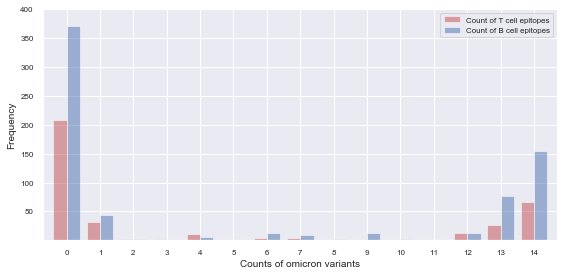

In [106]:
sns.set_theme()
fig = plt.figure()
ax = plt.gca()

plt.hist([t_epi_s["count_lin_mut"], b_epi_s["count_lin_mut"]]
              , color=['r','b'], alpha=0.5,bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5])

plt.xlabel("Counts of omicron variants", fontsize= 10)
plt.ylabel("Frequency", fontsize= 10)

plt.xticks((0,1,2,3,4,5,6,7,8,9,10,11,12,13,14), fontsize= 8)
plt.yticks((50,100,150,200,250,300,350,400) ,fontsize= 8)

plt.xlim((-0.7,14.7))
plt.ylim((0,400))

ax.legend(["Count of T cell epitopes", "Count of B cell epitopes"],loc='upper right', fontsize = 8, ncol=1)

fig.set_size_inches(8,4)
plt.tight_layout()
plt.show()

### NOTE: Running the next cell is very time consuming; also, it icludes the random re-positionning of the epitopes. Therefore, I did not run it and I upload the files that have been used in generating the figures of the manuscript

In [ ]:
df_t= pd.DataFrame(index=range(0,1000), columns=['All_count_var', 'factor_var_over_len','var_count','var_hit_count','factor'])
df_b= pd.DataFrame(index=range(0,1000), columns=['All_count_var', 'factor_var_over_len','var_count','var_hit_count','factor'])

for k in range(0,1000):
    All_count_var=[]
    factor_var_over_len=[]
    for i in range(len(t_epi_s)):
        start= random.randint(1,1273-t_epi_s['length'][i]+1)
        df= heat_S.iloc[:, start-1:int(start + t_epi_s['length'][i]-1)] #this is a splicer from spike heat map\n",

        var_list= df.apply(lambda row: sum(row>0), axis=1).tolist()
        factor_len= [j/t_epi_s['length'][i] for j in var_list] #here I divided the number of var at a position over the len of epitopes
        
        All_count_var.append(var_list)
        factor_var_over_len.append(factor_len)

    df_t['All_count_var'][k]= All_count_var
    df_t['factor_var_over_len'][k]= factor_var_over_len     
    
    All_count_var=[]
    factor_var_over_len=[]

    for i in range(len(b_epi_s)):
        start= random.randint(1,1273-b_epi_s['length'][i]+1)
        df= heat_S.iloc[:, start-1:int(start + b_epi_s['length'][i]-1)]

        var_list= df.apply(lambda row: sum(row>0), axis=1).tolist()
        factor_len= [j/b_epi_s['length'][i] for j in var_list]
        
        
        All_count_var.append(var_list)
        factor_var_over_len.append(factor_len)
        
  
    df_b['All_count_var'][k]= All_count_var
    df_b['factor_var_over_len'][k]= factor_var_over_len 
     

for i in range(0,1000):
    var_count=[]
    factor=[]
    for j in df_t['All_count_var'][i]:
        var_count.append(len(list(filter(lambda num: num != 0, j))))
    for k in df_t['factor_var_over_len'][i]:
        factor.append(sum(k))
    
    df_t['var_count'][i]= var_count
    df_t['var_hit_count'][i]= len(list(filter(lambda num: num != 0, df_t['var_count'][i])))
    df_t['factor'][i]= sum(factor)
    
    var_count=[]
    factor=[]
    for j in df_b['All_count_var'][i]:
        var_count.append(len(list(filter(lambda num: num != 0, j))))
    for k in df_b['factor_var_over_len'][i]:
        factor.append(sum(k))
    
    df_b['var_count'][i]= var_count
    df_b['var_hit_count'][i]= len(list(filter(lambda num: num != 0, df_b['var_count'][i])))
    df_b['factor'][i]= sum(factor)

In [109]:
df_t2=pd.read_csv('new_approach_monte_carlo_Tcell_epitope_75RF_with_1_repositioning_1K_times_with_counts.csv', index_col=0)
df_b2=pd.read_csv('new_approach_monte_carlo_Bcell_epitope_75RF_with_1_repositioning_1K_times_with_counts.csv', index_col=0)

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


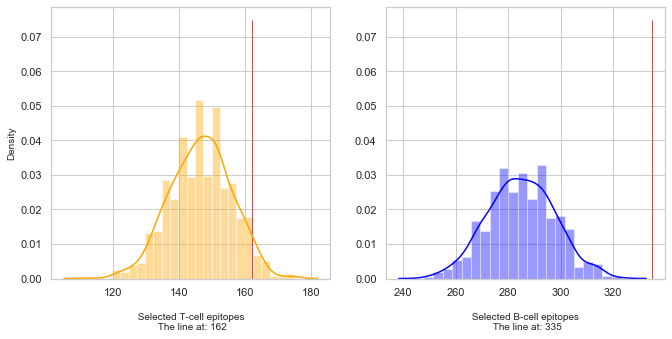

In [111]:
sns.set(style= "whitegrid")
fig, axes = plt.subplots(1,2, figsize=(11, 5))
fig= plt.gcf()

sns.distplot(df_t2['var_hit_count'], color= 'orange', ax=axes[0])
sns.distplot(df_b2['var_hit_count'], color='blue', ax=axes[1])


x1= len([k for k in t_epi_s['count_lin_mut'] if k>0])
x2= len([k for k in b_epi_s['count_lin_mut'] if k>0])

 
axes[0].set_xlabel(('\n Selected T-cell epitopes \n The line at: '+ str(x1)), fontsize=10)
axes[1].set_xlabel(('\n Selected B-cell epitopes \n The line at: '+ str(x2)), fontsize=10)

axes[0].vlines(x= x1, ymin=0, ymax=0.075, linewidth=1, color='r')
axes[1].vlines(x= x2, ymin=0, ymax=0.075, linewidth=1, color='r')


axes[0].set_ylabel("Density", fontsize=10)
axes[1].set_ylabel("\n", fontsize=10)



plt.show()

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Asus\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


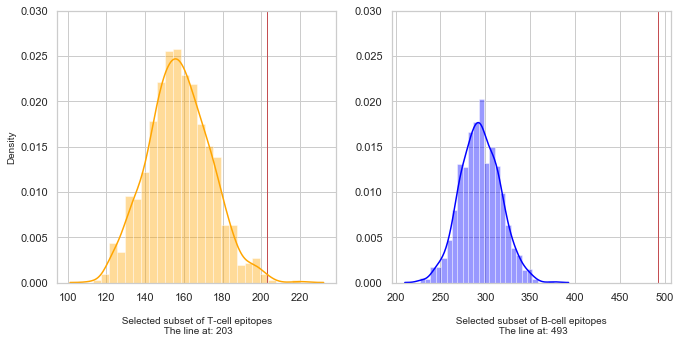

In [112]:
sns.set(style= "whitegrid")
fig, axes = plt.subplots(1,2, figsize=(11, 5))
fig= plt.gcf()

sns.distplot(df_t2['factor'], color= 'orange', ax=axes[0])
sns.distplot(df_b2['factor'], color='blue', ax=axes[1])


x1= int(sum(t_epi_s['factor']))
x2= int(sum(b_epi_s['factor']))

axes[0].set_xlabel(('\n Selected subset of T-cell epitopes \n The line at: '+ str(x1)), fontsize=10)#, labelpad=8)
axes[1].set_xlabel(('\n Selected subset of B-cell epitopes \n The line at: '+ str(x2)), fontsize=10)#, labelpad=8)

axes[0].vlines(x= x1, ymin=0, ymax=0.075, linewidth=1, color='r')
axes[1].vlines(x= x2, ymin=0, ymax=0.075, linewidth=1, color='r')


axes[0].set_ylabel("Density", fontsize=10)
axes[1].set_ylabel("\n", fontsize=10)


axes[0].set(ylim=(0, 0.03))
axes[1].set(ylim=(0, 0.03))

plt.show()